<a href="https://colab.research.google.com/github/shadyessam1/ai-cyber-lab/blob/main/notebooks/01_fastai_lesson1_login.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install -Uqq fastai ddgs

In [16]:
from fastai.vision.all import *
from fastdownload import download_url
from time import sleep

try:
    from ddgs import DDGS
except ImportError:
    from duckduckgo_search import DDGS

def search_images(term, max_images=200):
    print(f"Searching for '{term}'")
    results = DDGS().images(term, max_results=max_images)
    return L([r['image'] for r in results])

Searching for 'bird photos'
https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg


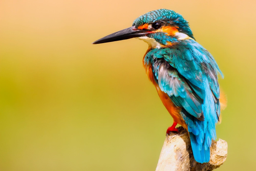

In [21]:
urls = search_images('bird photos', max_images=1)
print(urls[0])
download_url(urls[0], 'bird.jpg', show_progress=False)
Image.open('bird.jpg').to_thumb(256, 256)

In [22]:
searches = 'phishing_login', 'real_login'
queries = {
    'phishing_login': 'phishing login page screenshot',
    'real_login': 'bank login page screenshot',
}
path = Path('data/login_pages')

for o in searches:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(queries[o]))
    sleep(10)
    resize_images(path/o, max_size=400, dest=path/o)

Searching for 'phishing login page screenshot'
Searching for 'bank login page screenshot'


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [23]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
print(f'Removed {len(failed)} broken images')
for o in searches:
    print(o, len(get_image_files(path/o)))

Removed 2 broken images
phishing_login 65
real_login 66


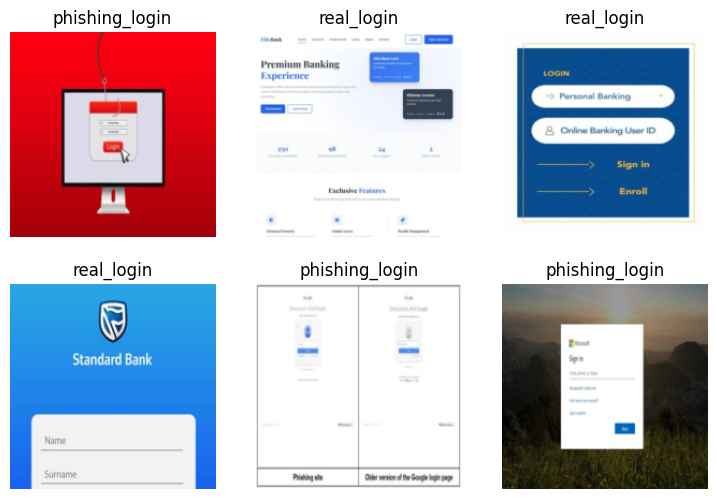

In [24]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)


In [25]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.395856,0.813914,0.384615,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.614734,0.449141,0.269231,00:00
1,0.427002,0.175256,0.076923,00:00
2,0.311447,0.116886,0.000000,00:00


In [26]:
err = learn.validate()[1]
print(f'Validation accuracy: {1 - err:.4f}')
print(f'Train: {len(dls.train_ds)} | Valid: {len(dls.valid_ds)}')

Validation accuracy: 1.0000
Train: 105 | Valid: 26
